In this notebook I do a similar analysis as the simulations just to real data (still evaluating the ability of the metrics to predict some parcellation evaluation metric in this case cos error). I used a frontal cortex ROI I made up. MDTB-s1 was used for training and predicition error was done using MDTB-s2 and only within voxels in the ROI used. Here since we are looking at predicition error, for evaluation of metric lower is better (e.g., the higher the log_det the lower the predicition error)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
from Functional_Fusion.dataset import DataSetMDTB
import os
import pickle
import Functional_Fusion.atlas_map as am
from IndividualParcellation.global_config import *
import OptimalBattery.evaluate as ev
import PcmPy as pcm
import seaborn as sns
import nilearn.plotting as plotting
import nitools as nt
import pandas as pd


Default device set to: cuda


# define atlas for data used and ROI mask dir

In [2]:
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/FunctionalFusion/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/FunctionalFusion/'
cort_dir = 'Y:/data/Atlas_templates/fs_LR_32'

# Get Vs for mdtb_1 and mdtb_2 from nettekoven 32

In [3]:
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models/Models_03/NettekovenSym32_space-MNISymC2_D5.pickle'
with open(model_dir, 'rb') as f:
    full_model = pickle.load(f)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V
VL_mdtb_1 = mdtb_1_Vs.cpu().numpy()

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V
VL_mdtb_2 = mdtb_2_Vs.cpu().numpy()


# Load data

In [4]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]


data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]



data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


In [5]:
# make a data of shape 1 x data_mdtb_s1_all.shape[2] of 1s
ROI_mask = np.ones((data_mdtb_s1_all.shape[2]),)

ROI_indices = np.where(ROI_mask == 1)[0]



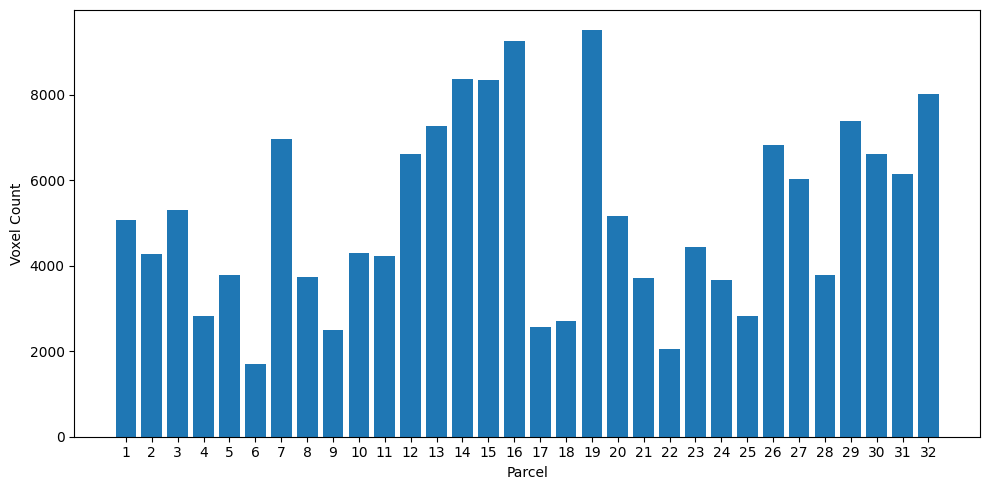

In [6]:
# make random noise data (baseline), project voxels to parcels and count voxel per parcel
data_mdtb_s1_all_noise = np.random.rand(data_mdtb_s1_all.shape[0],data_mdtb_s1_all.shape[1],data_mdtb_s1_all.shape[2])
total_parcel_counts = np.zeros(32)

for subject_data in data_mdtb_s1_all_noise:
    data = subject_data[:, ROI_indices]
    
    data_projected = VL_mdtb_1.T @ data
    data_projected_onehot = ev.get_U_hat_one_hot(data_projected)[0]
    
    total_parcel_counts += np.sum(data_projected_onehot, axis=1)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 33), total_parcel_counts, tick_label=range(1, 33))
plt.xlabel('Parcel')
plt.ylabel('Voxel Count')
plt.tight_layout()
plt.show()

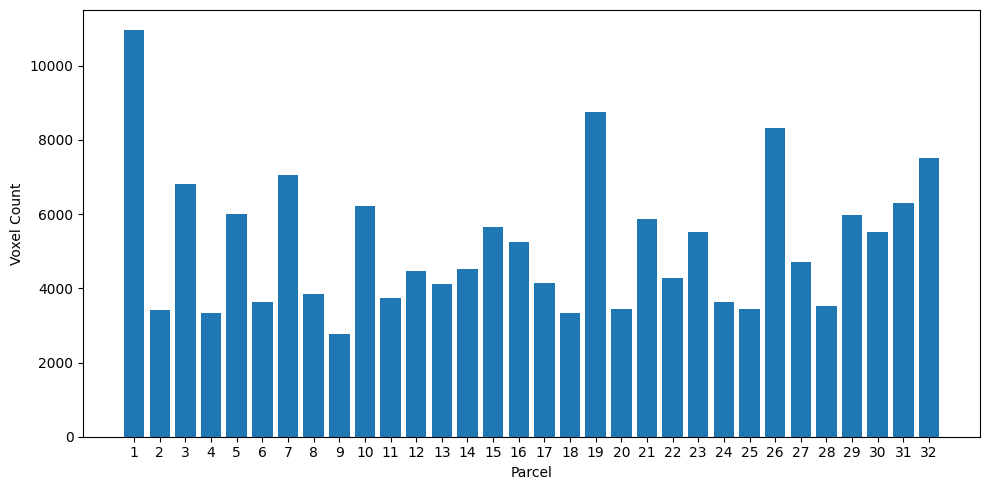

array([ 0, 18, 25, 31], dtype=int64)

In [7]:
# get top 4 parcels with highest voxel counts within ROI
total_parcel_counts = np.zeros(32)

for subject_data in data_mdtb_s1_all:
    data = subject_data[:, ROI_indices]
    
    data_projected = VL_mdtb_1.T @ data
    data_projected_onehot = ev.get_U_hat_one_hot(data_projected)[0]
    
    total_parcel_counts += np.sum(data_projected_onehot, axis=1)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 33), total_parcel_counts, tick_label=range(1, 33))
plt.xlabel('Parcel')
plt.ylabel('Voxel Count')
plt.tight_layout()
plt.show()

# choose 4 parcels with top voxel counts
top_parcels = np.argsort(total_parcel_counts)[::-1][:4]
top_parcels



pretty reasonable S and D region Vs seem to capture the biggest amount of voxels in the frontal cortex ROI

# subset VLib and Vtest to only include parcels with most voxels in ROI

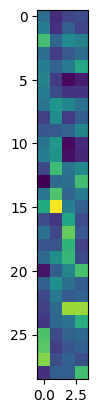

In [8]:
VLib = VL_mdtb_1[:,top_parcels]
plt.imshow(VLib)

In [10]:
vtest =  VL_mdtb_2[:,top_parcels]
vtest.shape

(32, 4)

# Get crossvalidated second moment matrix (GLib)

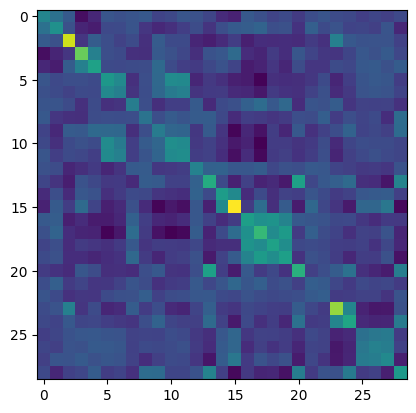

In [92]:
cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib)

In [93]:
metric = 'log_det_mc'

In [94]:
# D = ut.build_combinations(G_Lib, strategy='random',n_iter=70000,n_tasks=8,seed=1,replacement=False)

# # print min of of D['log_det_mc']
# min_idx = np.argmin(D[metric])
# print(f"min log det mc: {D.iloc[min_idx][metric]}")

# max_idx = np.argmax(D[metric])
# print(f"max log det mc: {D.iloc[max_idx][metric]}")

# std = np.std(D[metric])
# mean = np.mean(D[metric])

# print(f"std: {std}")
# print(f"mean: {mean}")

# coef_var = std/mean
# print(f"coef var: {coef_var}")

In [95]:
D = ut.build_combinations(G_Lib, strategy='random',n_iter=5000,n_tasks=4,seed=1,replacement=True)

# print min of of D['log_det_mc']
min_idx = np.argmin(D[metric])
print(f"min log det mc: {D.iloc[min_idx][metric]}")

max_idx = np.argmax(D[metric])
print(f"max log det mc: {D.iloc[max_idx][metric]}")

std = np.std(D[metric])
mean = np.mean(D[metric])

print(f"std: {std}")
print(f"mean: {mean}")

coef_var = std/mean
print(f"coef var: {coef_var}")

min log det mc: -89.76370846601276
max log det mc: -43.45796959846501
std: 8.961070647666418
mean: -50.6505337652592
coef var: -0.17691956987455768


In [96]:
D_ev = ev.evaluate_dataframe_real_multiregion(D, data_mdtb_s1_all,VLib,data_mdtb_s2_all, vtest,ROI_indices)


Processing combination: 0
Processing combination: 10
Processing combination: 20
Processing combination: 30
Processing combination: 40
Processing combination: 50
Processing combination: 60
Processing combination: 70
Processing combination: 80
Processing combination: 90
Processing combination: 100
Processing combination: 110
Processing combination: 120
Processing combination: 130
Processing combination: 140
Processing combination: 150
Processing combination: 160
Processing combination: 170
Processing combination: 180
Processing combination: 190
Processing combination: 200
Processing combination: 210
Processing combination: 220
Processing combination: 230
Processing combination: 240
Processing combination: 250
Processing combination: 260
Processing combination: 270
Processing combination: 280
Processing combination: 290
Processing combination: 300
Processing combination: 310
Processing combination: 320
Processing combination: 330
Processing combination: 340
Processing combination: 350
Pro

In [23]:
# save dataframe in current repo dataframes folder
save_path = os.path.join(os.getcwd(), '..', 'dataframes')
# D_ev.to_csv(os.path.join(save_path, 'cerebellum_MDTB_s1_s2_top8parcels_8tasks.tsv'), sep='\t', index=False)
# load
D_ev = pd.read_csv(os.path.join(save_path, 'cerebellum_MDTB_s1_s2_top8parcels_8tasks.tsv'), sep='\t')
D_sub= D_ev

In [24]:
# D_sub = D_ev[D_ev['n_unique'] == 6]
len(D_sub)

69873

(-10000.0, -100.0)

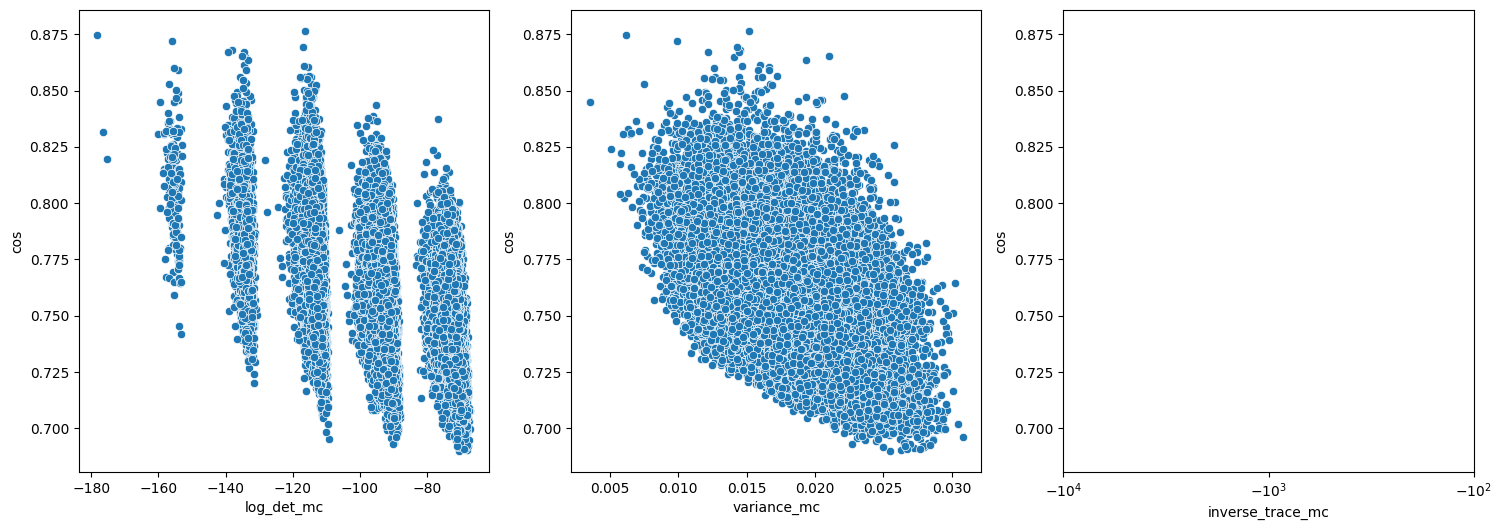

In [25]:

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
sns.scatterplot(data=D_sub, x='log_det_mc', y='cos', ax=ax[0])
sns.scatterplot(data=D_sub, x='variance_mc', y='cos', ax=ax[1])
sns.scatterplot(data=D_sub, x='inverse_trace_mc', y='cos', ax=ax[2])
ax[2].set_xscale('symlog', linthresh=1)
ax[2].set_xlim(-10000, -100)

In [26]:
D_sub['n_unique'].value_counts()


n_unique
7    30924
8    24196
6    12574
5     2046
4      130
3        3
Name: count, dtype: int64

In [31]:
sample_sizes = range(10, len(D_sub)+1, 1000) 
metrics = ['log_det_mc', 'variance', 'inverse_trace_mc']

correlation_data = []
for n in sample_sizes:
    # give updates
    if n % 1000 == 0:
        print(f'Processing sample size {n}')
    for metric in metrics:
        top_n = D_sub.nlargest(n, metric)
        # find mean of cos values for top n\
        mean_cos = top_n['cos'].mean()        
        correlation_data.append({
            'Sample Size': n,
            'Metric': metric,
            'mean_cos': mean_cos,
        })

correlation_df = pd.DataFrame(correlation_data)




(array([7.1000e+01, 4.6200e+02, 1.5830e+03, 4.1570e+03, 7.4800e+03,
        1.0373e+04, 1.1229e+04, 1.0323e+04, 8.2230e+03, 6.2480e+03,
        4.3250e+03, 2.7520e+03, 1.4200e+03, 7.2000e+02, 2.7300e+02,
        1.4000e+02, 5.2000e+01, 2.6000e+01, 9.0000e+00, 7.0000e+00]),
 array([0.68999591, 0.69931799, 0.70864008, 0.71796216, 0.72728424,
        0.73660633, 0.74592841, 0.75525049, 0.76457257, 0.77389466,
        0.78321674, 0.79253882, 0.80186091, 0.81118299, 0.82050507,
        0.82982716, 0.83914924, 0.84847132, 0.8577934 , 0.86711549,
        0.87643757]),
 <BarContainer object of 20 artists>)

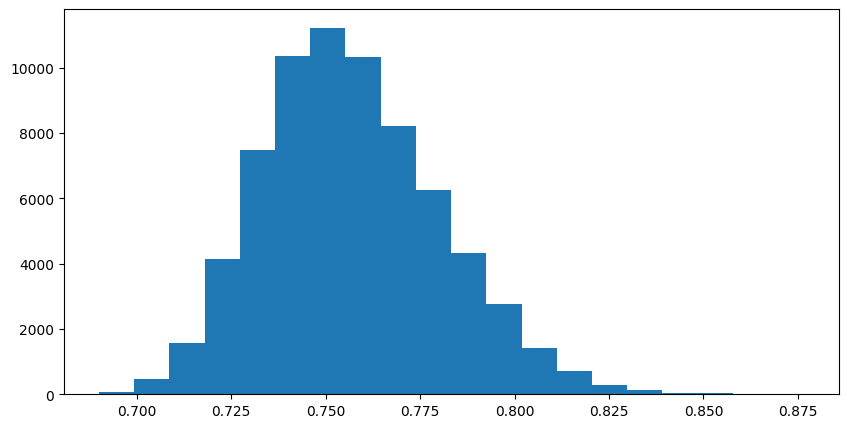

In [32]:
# plot cos values in D_sub
plt.figure(figsize=(10, 5))
plt.hist(D_sub['cos'], bins=20)

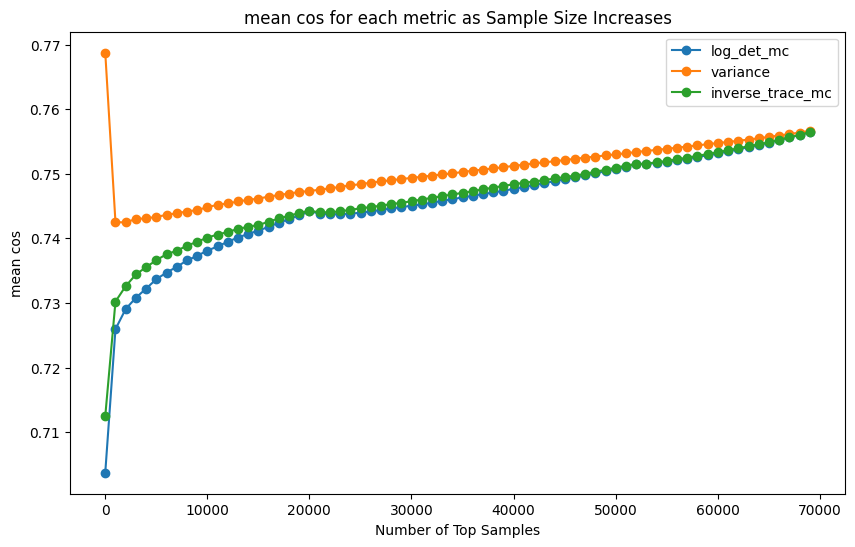

In [33]:
# Plotting Spearman
plt.figure(figsize=(10, 6))
for metric in metrics:
    subset = correlation_df[correlation_df['Metric'] == metric]
    plt.plot(subset['Sample Size'], subset['mean_cos'], label=metric, marker='o')
plt.title('mean cos for each metric as Sample Size Increases')
plt.xlabel('Number of Top Samples')
plt.ylabel('mean cos')
plt.legend()
plt.show()